# Исследование надежности заемщиков


Во второй части проекта вы выполните шаги 3 и 4. Их вручную проверит ревьюер.
Чтобы вам не пришлось писать код заново для шагов 1 и 2, мы добавили авторские решения в ячейки с кодом. 



## Откройте таблицу и изучите общую информацию о данных

**Задание 1. Импортируйте библиотеку pandas. Считайте данные из csv-файла в датафрейм и сохраните в переменную `data`. Путь к файлу:**

`/datasets/data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    data = pd.read_csv('/datasets/data.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/data.csv')

**Задание 2. Выведите первые 20 строчек датафрейма `data` на экран.**

In [2]:
data.head(20)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу
5,0,-926.185831,27,высшее,0,гражданский брак,1,M,компаньон,0,255763.565419,покупка жилья
6,0,-2879.202052,43,высшее,0,женат / замужем,0,F,компаньон,0,240525.971920,операции с жильем
7,0,-152.779569,50,СРЕДНЕЕ,1,женат / замужем,0,M,сотрудник,0,135823.934197,образование
8,2,-6929.865299,35,ВЫСШЕЕ,0,гражданский брак,1,F,сотрудник,0,95856.832424,на проведение свадьбы
9,0,-2188.756445,41,среднее,1,женат / замужем,0,M,сотрудник,0,144425.938277,покупка жилья для семьи


**Задание 3. Выведите основную информацию о датафрейме с помощью метода `info()`.**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


## Предобработка данных

### Удаление пропусков

**Задание 4. Выведите количество пропущенных значений для каждого столбца. Используйте комбинацию двух методов.**

In [4]:
data.isna().sum()

children               0
days_employed       2174
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income        2174
purpose                0
dtype: int64

**Задание 5. В двух столбцах есть пропущенные значения. Один из них — `days_employed`. Пропуски в этом столбце вы обработаете на следующем этапе. Другой столбец с пропущенными значениями — `total_income` — хранит данные о доходах. На сумму дохода сильнее всего влияет тип занятости, поэтому заполнить пропуски в этом столбце нужно медианным значением по каждому типу из столбца `income_type`. Например, у человека с типом занятости `сотрудник` пропуск в столбце `total_income` должен быть заполнен медианным доходом среди всех записей с тем же типом.**

In [5]:
for t in data['income_type'].unique():
    data.loc[(data['income_type'] == t) & (data['total_income'].isna()), 'total_income'] = \
    data.loc[(data['income_type'] == t), 'total_income'].median()

### Обработка аномальных значений

**Задание 6. В данных могут встречаться артефакты (аномалии) — значения, которые не отражают действительность и появились по какой-то ошибке. таким артефактом будет отрицательное количество дней трудового стажа в столбце `days_employed`. Для реальных данных это нормально. Обработайте значения в этом столбце: замените все отрицательные значения положительными с помощью метода `abs()`.**

In [6]:
data['days_employed'] = data['days_employed'].abs()

**Задание 7. Для каждого типа занятости выведите медианное значение трудового стажа `days_employed` в днях.**

In [7]:
data.groupby('income_type')['days_employed'].agg('median')

income_type
безработный        366413.652744
в декрете            3296.759962
госслужащий          2689.368353
компаньон            1547.382223
пенсионер          365213.306266
предприниматель       520.848083
сотрудник            1574.202821
студент               578.751554
Name: days_employed, dtype: float64

У двух типов (безработные и пенсионеры) получатся аномально большие значения. Исправить такие значения сложно, поэтому оставьте их как есть.

**Задание 8. Выведите перечень уникальных значений столбца `children`.**

In [8]:
data['children'].unique()

array([ 1,  0,  3,  2, -1,  4, 20,  5], dtype=int64)

**Задание 9. В столбце `children` есть два аномальных значения. Удалите строки, в которых встречаются такие аномальные значения из датафрейма `data`.**

In [9]:
data = data[(data['children'] != -1) & (data['children'] != 20)]

**Задание 10. Ещё раз выведите перечень уникальных значений столбца `children`, чтобы убедиться, что артефакты удалены.**

In [10]:
data['children'].unique()

array([1, 0, 3, 2, 4, 5], dtype=int64)

### Удаление пропусков (продолжение)

**Задание 11. Заполните пропуски в столбце `days_employed` медианными значениями по каждого типа занятости `income_type`.**

In [11]:
for t in data['income_type'].unique():
    data.loc[(data['income_type'] == t) & (data['days_employed'].isna()), 'days_employed'] = \
    data.loc[(data['income_type'] == t), 'days_employed'].median()

**Задание 12. Убедитесь, что все пропуски заполнены. Проверьте себя и ещё раз выведите количество пропущенных значений для каждого столбца с помощью двух методов.**

In [12]:
data.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

### Изменение типов данных

**Задание 13. Замените вещественный тип данных в столбце `total_income` на целочисленный с помощью метода `astype()`.**

In [13]:
data['total_income'] = data['total_income'].astype(int)

### Обработка дубликатов

**Задание 14. Обработайте неявные дубликаты в столбце `education`. В этом столбце есть одни и те же значения, но записанные по-разному: с использованием заглавных и строчных букв. Приведите их к нижнему регистру.**

In [14]:
data['education'] = data['education'].str.lower()

**Задание 15. Выведите на экран количество строк-дубликатов в данных. Если такие строки присутствуют, удалите их.**

In [15]:
data.duplicated().sum()

71

In [16]:
data = data.drop_duplicates()

### Категоризация данных

**Задание 16. На основании диапазонов, указанных ниже, создайте в датафрейме `data` столбец `total_income_category` с категориями:**

- 0–30000 — `'E'`;
- 30001–50000 — `'D'`;
- 50001–200000 — `'C'`;
- 200001–1000000 — `'B'`;
- 1000001 и выше — `'A'`.


**Например, кредитополучателю с доходом 25000 нужно назначить категорию `'E'`, а клиенту, получающему 235000, — `'B'`. Используйте собственную функцию с именем `categorize_income()` и метод `apply()`.**

In [17]:
def categorize_income(income):
    try:
        if 0 <= income <= 30000:
            return 'E'
        elif 30001 <= income <= 50000:
            return 'D'
        elif 50001 <= income <= 200000:
            return 'C'
        elif 200001 <= income <= 1000000:
            return 'B'
        elif income >= 1000001:
            return 'A'
    except:
        pass

In [18]:
data['total_income_category'] = data['total_income'].apply(categorize_income)

**Задание 17. Выведите на экран перечень уникальных целей взятия кредита из столбца `purpose`.**

In [19]:
data['purpose'].unique()

array(['покупка жилья', 'приобретение автомобиля',
       'дополнительное образование', 'сыграть свадьбу',
       'операции с жильем', 'образование', 'на проведение свадьбы',
       'покупка жилья для семьи', 'покупка недвижимости',
       'покупка коммерческой недвижимости', 'покупка жилой недвижимости',
       'строительство собственной недвижимости', 'недвижимость',
       'строительство недвижимости', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля',
       'операции с коммерческой недвижимостью',
       'строительство жилой недвижимости', 'жилье',
       'операции со своей недвижимостью', 'автомобили',
       'заняться образованием', 'сделка с подержанным автомобилем',
       'получение образования', 'автомобиль', 'свадьба',
       'получение дополнительного образования', 'покупка своего жилья',
       'операции с недвижимостью', 'получение высшего образования',
       'свой автомобиль', 'сделка с автомобилем',
       'профильное образование', 'высшее об

**Задание 18. Создайте функцию, которая на основании данных из столбца `purpose` сформирует новый столбец `purpose_category`, в который войдут следующие категории:**

- `'операции с автомобилем'`,
- `'операции с недвижимостью'`,
- `'проведение свадьбы'`,
- `'получение образования'`.

**Например, если в столбце `purpose` находится подстрока `'на покупку автомобиля'`, то в столбце `purpose_category` должна появиться строка `'операции с автомобилем'`.**

**Используйте собственную функцию с именем `categorize_purpose()` и метод `apply()`. Изучите данные в столбце `purpose` и определите, какие подстроки помогут вам правильно определить категорию.**

In [20]:
def categorize_purpose(row):
    try:
        if 'автом' in row:
            return 'операции с автомобилем'
        elif 'жил' in row or 'недвиж' in row:
            return 'операции с недвижимостью'
        elif 'свад' in row:
            return 'проведение свадьбы'
        elif 'образов' in row:
            return 'получение образования'
    except:
        return 'нет категории'

In [21]:
data['purpose_category'] = data['purpose'].apply(categorize_purpose)

### Шаг 3. Исследуйте данные и ответьте на вопросы

In [22]:
grouped_data = (
    data.groupby('purpose_category')['debt']
    .agg(['count', 'sum', 'mean']))

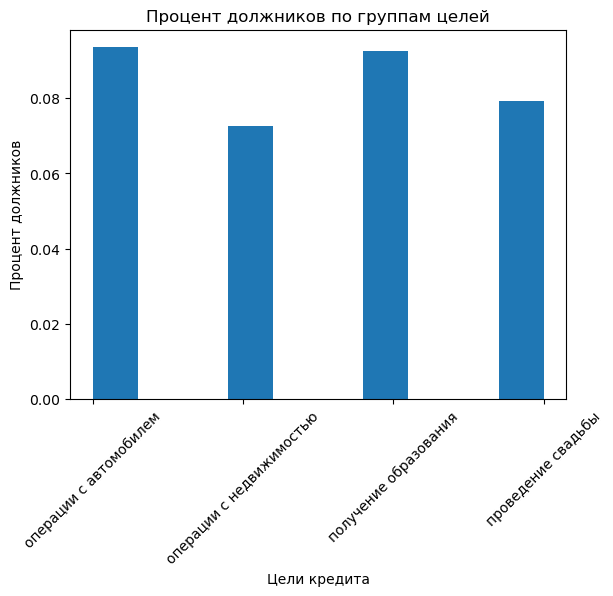

In [23]:
plt.hist(grouped_data.index, weights=grouped_data['mean']) # График по сгруппированным данным
plt.title('Процент должников по группам целей')
plt.xlabel('Цели кредита')
plt.ylabel('Процент должников')
plt.xticks(rotation=45)
plt.show() # Убирает описание настроек перед графиком

#### 3.1 Есть ли зависимость между количеством детей и возвратом кредита в срок?

In [24]:
import math
import numpy

debt_all=data['debt'].mean()
sigma = math.sqrt(debt_all*(1-debt_all))

# создает сводную таблицу и оценивает правдоподобность того, что исследуемый фактор не влияет на возврат кредита
def new_data(col):
    res = data.pivot_table(index=[col], values='debt', aggfunc=["sum", 'count', "mean"])
    res['percent']=res[('mean', 'debt')].round(3)*100
    res['expected_debt_none']=res['count']*debt_all    
    res['delta']=(res['expected_debt_none']-res[('sum', 'debt')]).abs()
    res['delta_in_sigma'] = res['delta']/(sigma*numpy.sqrt(res[('count', 'debt')]))
    return res

In [25]:
stat_by_children=new_data('children')

#Люди без детей несколько выбиваются, оценим версию что влияет наличие, но не количество детей

debt_with_children=data[data['children']>0]['debt'].mean()
sigma1 = math.sqrt(debt_with_children*(1-debt_with_children))

print(f'доля неплательщиков среди людей с детьми {debt_with_children}\nдоля неплательщиков среди всех людей     {debt_all}')

stat_by_children['expected_debt_presence'] = stat_by_children['count']*debt_with_children

stat_by_children.loc[0,'expected_debt_presence']=None
stat_by_children['delta1']=(stat_by_children['expected_debt_presence']-stat_by_children[('sum', 'debt')]).abs()

stat_by_children['delta1_in_sigma'] = stat_by_children['delta1']/(sigma1*numpy.sqrt(stat_by_children[('count', 'debt')]))
stat_by_children

доля неплательщиков среди людей с детьми 0.09240331491712707
доля неплательщиков среди всех людей     0.08119638085415593


,sum,count,mean,percent,expected_debt_none,delta,delta_in_sigma,expected_debt_presence,delta1,delta1_in_sigma
,debt,debt,debt,,,,,,,
children,,,,,,,,,,
0,1063,14091,0.075438,7.5,1144.138203,81.138203,2.502504,NaN,NaN,NaN
1,444,4808,0.092346,9.2,390.392199,53.607801,2.830519,444.275138,0.275138,0.013702
2,194,2052,0.094542,9.5,166.614974,27.385026,2.213323,189.611602,4.388398,0.334524
3,27,330,0.081818,8.2,26.794806,0.205194,0.041355,30.493094,3.493094,0.663992
4,4,41,0.097561,9.8,3.329052,0.670948,0.383634,3.788536,0.211464,0.114039
5,0,9,0.000000,0.0,0.730767,0.730767,0.891822,0.831630,0.831630,0.957235


**Вывод:** 
* Предположение о том что наличие детей не влияет на задолженности оказалось неправдоподобным (в трех строках с наибольшим 
размером выборки отклонение более двух сигм).
* Предположение о том что влияет наличие детей, но не их количество выглядит вполне правдоподобным (все отклонения менее одной сигма).

#### 3.2 Есть ли зависимость между семейным положением и возвратом кредита в срок?

In [26]:
print(debt_all)
stat_by_family_status=new_data('family_status')
stat_by_family_status


0.08119638085415593


,sum,count,mean,percent,expected_debt_none,delta,delta_in_sigma
,debt,debt,debt,,,,
family_status,,,,,,,
Не женат / не замужем,273,2796,0.097639,9.8,227.025081,45.974919,3.183264
в разводе,84,1189,0.070648,7.1,96.542497,12.542497,1.331721
вдовец / вдова,63,951,0.066246,6.6,77.217758,14.217758,1.687956
гражданский брак,385,4134,0.093130,9.3,335.665838,49.334162,2.809201
женат / замужем,927,12261,0.075606,7.6,995.548826,68.548826,2.266509


Между семейным положением и возвратом кредита в срок прослеживается связь, при этом кажется что "более поздние" семейные положения возвращают в срок чаще. Проверим это предположение, рассмотрев отдельные возрастные группы.

In [30]:
def categorize_age(row):
    try:
        if(row==0):
            return 'не указан'
        elif row<30:
            return '10-30'
        elif row <40:
            return '30-39'
        elif row <50:
            return '40-49'
        elif row<60:
            return '50-59'
        elif row>60:
            return '60+'
    except:
        return 'не указан'

data['categorize_age'] = data['dob_years'].apply(categorize_age)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose,total_income_category,purpose_category,categorize_age
0,1,8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875,покупка жилья,B,операции с недвижимостью,40-49
1,1,4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080,приобретение автомобиля,C,операции с автомобилем,30-39
2,0,5623.422610,33,среднее,1,женат / замужем,0,M,сотрудник,0,145885,покупка жилья,C,операции с недвижимостью,30-39
3,3,4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628,дополнительное образование,B,получение образования,30-39
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616,сыграть свадьбу,C,проведение свадьбы,50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21520,1,4529.316663,43,среднее,1,гражданский брак,1,F,компаньон,0,224791,операции с жильем,B,операции с недвижимостью,40-49
21521,0,343937.404131,67,среднее,1,женат / замужем,0,F,пенсионер,0,155999,сделка с автомобилем,C,операции с автомобилем,60+
21522,1,2113.346888,38,среднее,1,гражданский брак,1,M,сотрудник,1,89672,недвижимость,C,операции с недвижимостью,30-39
21523,3,3112.481705,38,среднее,1,женат / замужем,0,M,сотрудник,1,244093,на покупку своего автомобиля,B,операции с автомобилем,30-39


In [31]:
pivot_age_status=data.pivot_table(index=['categorize_age','family_status'], values='debt', aggfunc=["sum", 'count', "mean"])
pivot_age_status['percent']=pivot_age_status[('mean', 'debt')].round(3)*100  
pivot_age_status['avg_debt_by_age_cat']=0

#уверена что это можно сделать средствами pivot_table, но не смогла разобраться как.
data_age = data.groupby('categorize_age')[['debt']].mean()
for (a,b) in pivot_age_status.index:
    pivot_age_status.loc[(a,b), 'avg_debt_by_age_cat'] = data_age.loc[a,'debt']

pivot_age_status['percent_by_age_cat']=pivot_age_status['avg_debt_by_age_cat'].round(3)*100    
pivot_age_status['expected_debt']=pivot_age_status[('count','debt')]*pivot_age_status['avg_debt_by_age_cat']    
pivot_age_status['delta']=(pivot_age_status['expected_debt']-pivot_age_status[('sum', 'debt')]).abs()
pivot_age_status['sigma']=numpy.sqrt(pivot_age_status['avg_debt_by_age_cat']*(1-pivot_age_status['avg_debt_by_age_cat']))
pivot_age_status['delta_in_sigma'] = pivot_age_status['delta']/(pivot_age_status['sigma']*numpy.sqrt(pivot_age_status[('count', 'debt')]))
pivot_age_status

C:\Users\USER\AppData\Local\Temp\ipykernel_21912\558472371.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.1102337334175616' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pivot_age_status.loc[(a,b), 'avg_debt_by_age_cat'] = data_age.loc[a,'debt']


sum count      mean percent  \
                                     debt  debt      debt           
categorize_age family_status                                        
10-30          Не женат / не замужем  103   914  0.112691    11.3   
               в разводе               14    94  0.148936    14.9   
               вдовец / вдова           0     2  0.000000     0.0   
               гражданский брак        70   683  0.102489    10.2   
               женат / замужем        162  1473  0.109980    11.0   
30-39          Не женат / не замужем   83   693  0.119769    12.0   
               в разводе               19   260  0.073077     7.3   
               вдовец / вдова           3    41  0.073171     7.3   
               гражданский брак       137  1162  0.117900    11.8   
               женат / замужем        306  3469  0.088210     8.8   
40-49          Не женат / не замужем   46   522  0.088123     8.8   
               в разводе               21   368  0.057065     5.7   
               вдовец / вдова          11   131  0.083969     8.4   
               гражданский брак        93  1076  0.086431     8.6   
               женат / замужем        230  3221  0.071406     7.1   
50-59          Не женат / не замужем   31   412  0.075243     7.5   
               в разводе               19   302  0.062914     6.3   
               вдовец / вдова          21   374  0.056150     5.6   
               гражданский брак        65   799  0.081352     8.1   
               женат / замужем        167  2744  0.060860     6.1   
60+            Не женат / не замужем    7   195  0.035897     3.6   
               в разводе                9   128  0.070312     7.0   
               вдовец / вдова          21   348  0.060345     6.0   
               гражданский брак        14   335  0.041791     4.2   
               женат / замужем         50  1112  0.044964     4.5   
не указан      Не женат / не замужем    1    16  0.062500     6.2   
               в разводе                0    10  0.000000     0.0   
               вдовец / вдова           1     5  0.200000    20.0   
               гражданский брак         2    21  0.095238     9.5   
               женат / замужем          4    48  0.083333     8.3   

                                     avg_debt_by_age_cat percent_by_age_cat  \
                                                                              
categorize_age family_status                                                  
10-30          Не женат / не замужем            0.110234               11.0   
               в разводе                        0.110234               11.0   
               вдовец / вдова                   0.110234               11.0   
               гражданский брак                 0.110234               11.0   
               женат / замужем                  0.110234               11.0   
30-39          Не женат / не замужем            0.097422                9.7   
               в разводе                        0.097422                9.7   
               вдовец / вдова                   0.097422                9.7   
               гражданский брак                 0.097422                9.7   
               женат / замужем                  0.097422                9.7   
40-49          Не женат / не замужем            0.075404                7.5   
               в разводе                        0.075404                7.5   
               вдовец / вдова                   0.075404                7.5   
               гражданский брак                 0.075404                7.5   
               женат / замужем                  0.075404                7.5   
50-59          Не женат / не замужем            0.065429                6.5   
               в разводе                        0.065429                6.5   
               вдовец / вдова                   0.065429                6.5   
               гражданский брак                 0.065429                6.5   
               женат /

**Вывод:** 
* Предположение о том что семейное положение не влияет на задолженности оказалось неправдоподобным (в трех строках с наибольшим размером выборки отклонение более двух сигм).
* Для разных возрастных категорий влияние семейного положения на задолженность различно. При этом, для всех групп, кроме "30-39" оно достаточно мало. Не состоящие в браке или состоящие в гражданском браке чаще не оплачивают кредиты вовремя. 

#### 3.3 Есть ли зависимость между уровнем дохода и возвратом кредита в срок?

In [ ]:
print(debt_all)
stat_by_total_income_category=new_data('total_income_category')
stat_by_total_income_category

**Вывод:** 
* Люди со средним доходом (категория "C") задерживают выплаты чаще чем люди с доходами выше и ниже среднего ("B" и "D"). 
* Про людей с очень высоким или очень низким доходом невозможно сделать никаких выводов так как их очень мало.

#### 3.4 Как разные цели кредита влияют на его возврат в срок?

In [ ]:
print(debt_all)
stat_by_total_purpose_category=new_data('purpose_category')
stat_by_total_purpose_category

**Вывод:** 
* Все платят ипотеку:)
* Цель кредита влияет на вероятность его своевременного погашения
* Кредиты на недвижимость и свадьбы оплачиваются вовремя чаще чем кредиты на автомобили и образование

#### 3.5 Приведите возможные причины появления пропусков в исходных данных.

*Ответ:* 

Пропуски бывают трёх типов: 
* Полностью случайные — забыли заполнить
* Случайные — данных, которыми можно было бы заполнить не существует
* Неслучайные — данные специально скрываются

#### 3.6 Объясните, почему заполнить пропуски медианным значением — лучшее решение для количественных переменных.

*Ответ:* Среднее значение некорректно характеризует данные, когда часть значений сильно отличается от большинства. В таких случаях лучше использовать медиану, она даст более репрезентативное значение.

### Шаг 4: общий вывод.

#### Предобработка
При предварительном анализе и обработке полученных от заказчика данных были произведены следующие действия:
1.  Обнаружены пропуски в данных по ежемесячным доходам  клиентов. Недостающие сведения были заполнены медианным значением в зависимости от типа занятости клиента. Для удобства, после дополнения данных, ежемесячный доход округлили до целочисленного значения 
1. Некоторые значения в  данных о количестве дней трудового стажа оказались отрицательными и были заменены на значение по модулю
1. Данные по клиентам с аномальным количеством детей  были удалены во избежание искажения результатов 
1. Данные проверены на дубликаты и очищены от них
1. Для дальнейшего анализа каждому клиенту была присвоена категория дохода
1. Также цель кредита были поделены на категории  “операции с автомобилем”, “операции с недвижимостью”, “проведение свадьбы” и “‘получение образования’”


#### Влияние количества детей
При анализе влияния количества детей были рассчитаны вероятности просрочки кредита в зависимости от количества детей.  По полученным данным была выдвинута и подтверждена гипотеза, что влияет факт наличия детей, а не их количество. 


| Категория клиентов | Процент должников  | 
|:------------- |:---------------|
|Клиенты с детьми       | 9.2%        |
| Клиенты без детей        | 7.5%        |

Наличие детей увеличивает вероятность просрочки по кредиту по сравнению с бездетными в 1.23 раза

#### Влияние семейного положения

При анализе влияния семейного статуса на факт погашения кредита в срок были рассчитаны вероятности просрочки кредита в зависимости от семейного положения.


| Категория клиентов | Процент должников  | 
|:------------- |:---------------|
|Не женат / не замужем|9.8%|
|в разводе|7.1%|
|вдовец / вдова|6.6%|
|гражданский брак|9.3%|
|женат / замужем|7.6%|

Между семейным положением и возвратом кредита в срок прослеживается связь, при этом кажется что "более поздние" семейные положения возвращают в срок чаще.


| Возраст | Семейный статус|Доля должников по возрасту и семейному статусу|Доля должников по возрастной группе | 
|:------------- |:---------------|:---------------|:---------------|
|10-30|Не женат / не замужем|11.3%|11.0%|
||в разводе|14.9%|11.0%|
||вдовец / вдова|0.0%|11.0%|
||гражданский брак|10.2%|11.0%|
||женат / замужем|11.0%|11.0%|
|30-39|Не женат / не замужем|12.0%|9.7%|
||в разводе|7.3%|9.7%|
||вдовец / вдова|7.3%|9.7%|
||гражданский брак|11.8%|9.7%|
||женат / замужем|8.8%|9.7%|
|40-49|Не женат / не замужем|8.8%|7.5%|
||в разводе|5.7%|7.5%|
||вдовец / вдова|8.4%|7.5%|
||гражданский брак|8.6%|7.5%|
||женат / замужем|7.1%|7.5%|
|50-59|Не женат / не замужем|7.5%|6.5%|
||в разводе|6.3%|6.5%|
||вдовец / вдова|5.6%|6.5%|
||гражданский брак|8.1%|6.5%|
||женат / замужем|6.1%|6.5%|
|60+|Не женат / не замужем|3.6%|4.8%|
||в разводе|7.0%|4.8%|
||вдовец / вдова|6.0%|4.8%|
||гражданский бра|4.2%|4.8%|
||женат / замужем|4.5%|4.8%|

Для разных возрастных категорий влияние семейного положения на задолженность различно. При этом, для всех групп, кроме "30-39" оно достаточно мало. 
* Люди никогда не состоявшие в официальном браке чаще не оплачивают кредиты вовремя (примерно в 1.2 раза)
* Клиенты в возрасте до 30 лет в 1.5 раза чаще имеют задолженность по кредиту чем клиенты в возрасте 50-59 лет и в 1.3 раза чаще чем клиенты в возрасте 40-49
* Не состоявшие в официальном браке клиенты в возрасте 30-39 лет в 1.34 раза чаще имеют задолженность по кредиту чем  состоящие в браке той же возрастной категории.

#### Влияние уровня дохода
| Уровень дохода | Процент должников  | 
|:------------- |:---------------|
| 0–30000 — `'E'`;|8.0%|
| 30001–50000 — `'D'`;|7.1%|
| 50001–200000 — `'C'`;|8.5%|
| 200001–1000000 — `'B'`;|6.0%|
| 1000001 и выше — `'A'`.|9.1%|

* Клиенты со средним доходом (категория "C") задерживают выплаты в 1.2-1.4 раза чаще чем люди с доходами выше и ниже среднего ("B" и "D"). При этом к категории "C" относится абсолютное большинство клиентов.
* Про клиентов с очень высоким или очень низким доходом невозможно сделать никаких выводов так как их очень мало.

#### Влияние цели кредита
| Цель кредита | Процент должников  | 
|:------------- |:---------------|						
|операции с автомобилем|9.3%|
|операции с недвижимостью|7.3%|
|получение образования|9.3%|
|проведение свадьбы|7.9%|

Выплаты за кредиты на автомобили и образование задерживают в 1.2-1.3 раза чаще чем кредиты на  недвижимость и свадьбы 

#### Итог и рекомендации
Все проанализированные параметры в той или иной степени влияют на вероятность своевременной выплаты кредита.

Наиболее значимыми факторами являются:
1. Возраст
1. Наличие детей
1. Цель кредита

Наименее значимым фактором является уровень дохода.

Влияние семейного положения неочевидно и должно быть рассмотрено в совокупности с другими факторами.

Портрет наиболее благоприятного клиента:
* Состоящий или состоявший ранее в браке
* Без детей 
* Старше 50 лет
* Цель кредита — операции с недвижимостью
* Доход выше среднего
